# Functions

In [89]:
import pandas as pd
import numpy as np 
import struc_dist.rna_utils as ru

def get_min_mean(fam):
    min_dists = ru.table_min_inter_fam(fam)
    mean_dists = ru.table_inter_fam(fam)
    df_min = pd.DataFrame.from_dict(min_dists, orient="index")
    df_mean = pd.DataFrame.from_dict(mean_dists, orient="index")
    return df_min, df_mean

def get_avg_min_mean(fam):
    min_dists = ru.table_avg_min_intra_fam(fam)
    mean_dists = ru.table_inter_fam(fam)
    df_min = pd.DataFrame.from_dict(min_dists, orient="index")
    df_mean = pd.DataFrame.from_dict(mean_dists, orient="index")
    return df_min, df_mean

def make_long_df(df, value_name="Distancia"):
    df_long = df.reset_index().melt(
        id_vars="index", var_name="Familia", value_name=value_name
    )
    df_long.rename(columns={"index": "Condición"}, inplace=True)
    return df_long


def reorder_df_by_diagonal(df, fixed_order=True):
    fixed_labels = [
    "telomerase",
    "5s",
    "tRNA",
    "tmRNA",
    "RNaseP",
    "23s",
    "grp1",
    "srp",
    "16s",
    ]
    # Asegurarse de que el índice y las columnas coincidan
    common = df.index.intersection(df.columns)
    # Obtener los valores diagonales
    diagonal = df.loc[common, common].values.diagonal()
    # Crear un orden basado en la diagonal (de mayor a menor)
    ordered_labels = common[np.argsort(-diagonal)]  # el "-" es para ordenar descendente
    # Reordenar el DataFrame
    if fixed_order:
        df_sorted = df.loc[fixed_labels, fixed_labels]
    else:
        df_sorted = df.loc[ordered_labels, ordered_labels]
    return df_sorted

def get_dfs(dists_paths, META_PATH):
    """
    Carga y procesa las matrices de distancia estructural filtradas.
    """
    dists = ["full", "dist100", "dist200", "dist400"]
    dfs = {}
    meta = {}
    fams = {}
    mins = {}
    means = {}
    avg_mins = {}
    for d in dists:
        dfs[d], meta[d] = ru.load_and_align(corr_path=dists_paths[d], meta_path=META_PATH)
    dfs_ref = dfs["full"].copy()
    for d in dists:
        dfs[d] = dfs[d] / dfs_ref.max().max()
        fams[d] = ru.build_inter_fam_corrs(dfs[d], meta[d])
        mins[d], means[d] = get_min_mean(fams[d])
        avg_mins[d], _ = get_avg_min_mean(fams[d])
        mins[d] = reorder_df_by_diagonal(mins[d], fixed_order=True)
        means[d] = reorder_df_by_diagonal(means[d], fixed_order=True)
        avg_mins[d] = reorder_df_by_diagonal(avg_mins[d], fixed_order=True)
        
    return mins, means, avg_mins
    

In [90]:
from pathlib import Path

DATA_PATH    = Path("/home/gkulemeyer/Documents/Repos/RNA-analysis/DataAnalysis/data/")
META_PATH    = DATA_PATH / "sources/ArchiveII_with_prob_and_motiv.csv"
DIST_PATH    = DATA_PATH / "rnadist_f_all.h5"

FILTERS = [100, 200, 400]
METRICS = ["mins", "means", "avg_mins"]

prefix_by_strategy = {
    "sortS": "rnadist_filtered",
    "clusS": "hc_filtered",
    "randS": "samples_filtered",
}

paths_by_strategy = {}
for s, prefix in prefix_by_strategy.items():
    dist_paths = {"full": DIST_PATH}
    for n in FILTERS:
        dist_paths[f"dist{n}"] = DATA_PATH / f"{prefix}{n}.h5"
    paths_by_strategy[s] = dist_paths

strategies = {}
for s, dist_paths in paths_by_strategy.items():
    dfs = get_dfs(dist_paths, META_PATH)
    metric_map = {}
    for i, metric in enumerate(METRICS):
        metric_map[metric] = dfs[i]
    strategies[s] = metric_map

delta_S = {}
for s, strategy_S in strategies.items():
    delta_S[s] = {}
    for metric, group in strategy_S.items():
        if "full" not in group:
            continue

        base = group["full"]
        delta_S[s][metric] = {}

        for dkey, df in group.items():
            if dkey == "full":
                continue
            delta_S[s][metric][dkey] = df - base

In [91]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("white")

fig_width1col = 9.66
fig_height = 9.0
font_size = 7

save_path = Path("figures/struc_dist_inter_join")

# print(delta_S['sortS']['mins'].keys())
# dict_keys(['sortS', 'clusS', 'randS'])
# dict_keys(['mins', 'means', 'avg_mins'])
# dict_keys(['dist100', 'dist200', 'dist400'])

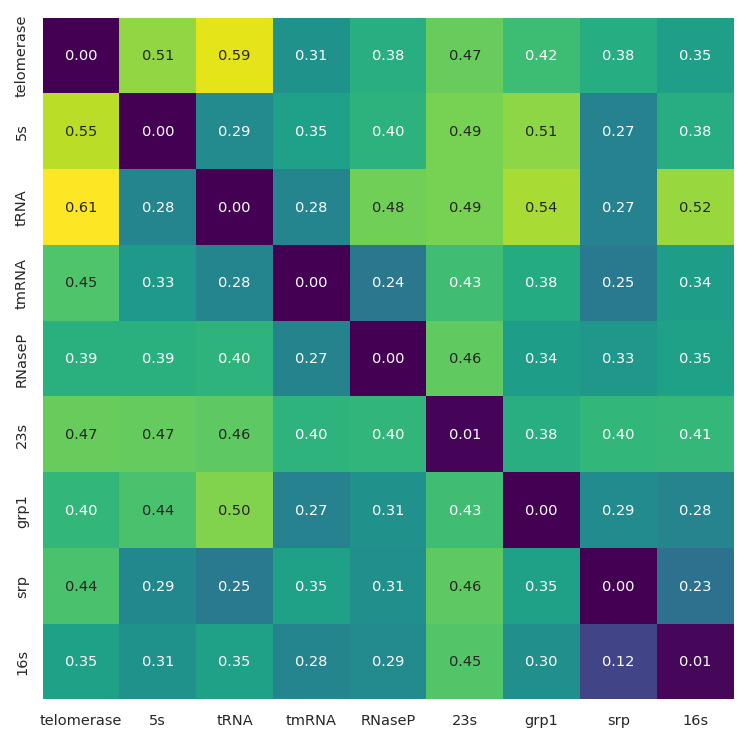

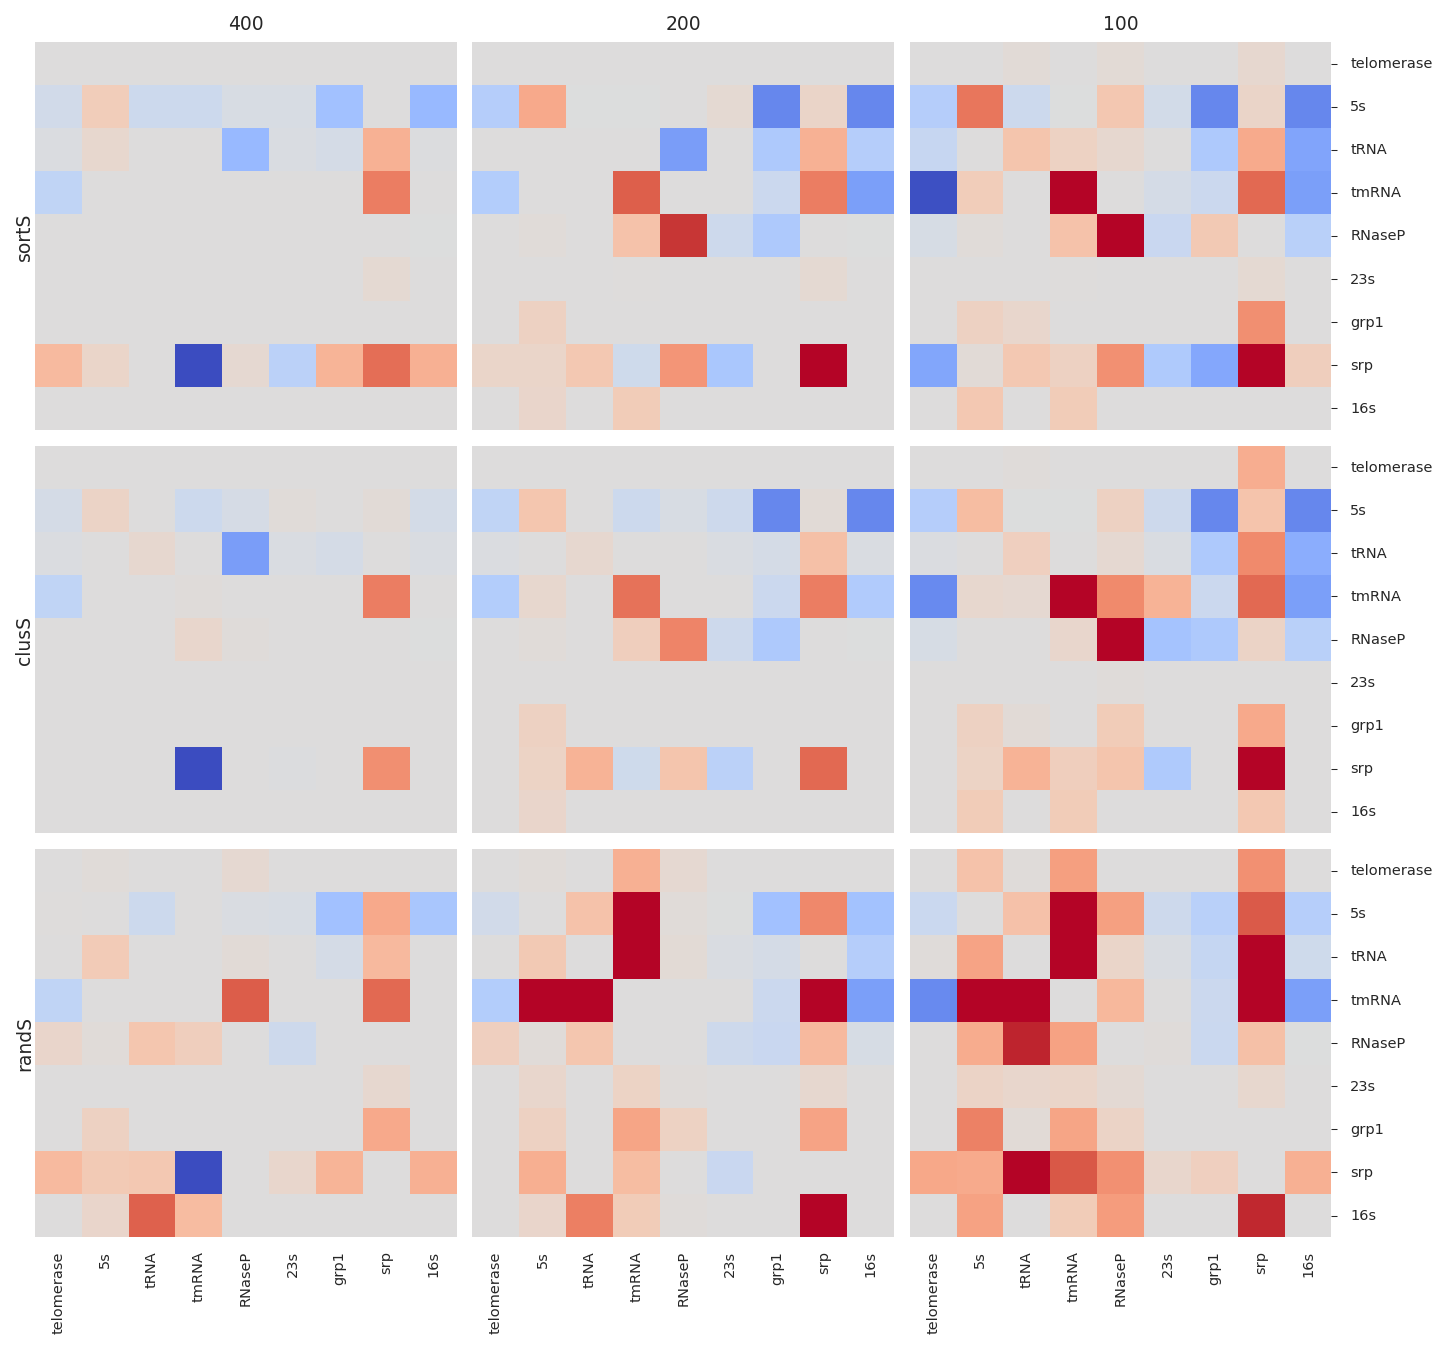

In [92]:
### mins ###
plt.figure(figsize=(5, 5), dpi=150)
sns.heatmap(strategies["sortS"]["mins"]["full"], annot=True, cmap="viridis", fmt=".2f", cbar=False)
plt.rcParams.update({'font.size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)
plt.tight_layout()
plt.savefig(save_path / "mins_full.svg", dpi=150)
plt.show()

fig, ax = plt.subplots(3,3, figsize=(fig_width1col, fig_height), sharex=True, sharey=True, dpi=150)
plt.rcParams.update({'font.size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)

for row_idx, row in enumerate(["sortS", "clusS", "randS"]):
    for col_idx, col in enumerate(["dist400", "dist200","dist100"]):
        a = ax[row_idx, col_idx]
        sns.heatmap(
            delta_S[row]["mins"][col],
            annot=False,
            cmap="coolwarm", 
            cbar=False, 
            vmin=-0.1, 
            vmax=0.1,
            ax=a
            )
        

        if row_idx == 0:
            a.set_title(col.replace("dist", ""), fontsize=font_size+2) 
        if col_idx == 0:
            a.set_ylabel(row, rotation=90, labelpad=5, va="center", fontsize=font_size+2)
        else:
            a.set_ylabel("")
            
        a.tick_params(axis="y", left=False, labelleft=False)
        if col_idx == 2:
            a.yaxis.tick_right()
            a.tick_params(axis="y", right=True, labelright=True, pad=6, labelsize=font_size)
            a.set_yticklabels(a.get_yticklabels(), rotation=0, ha="left", va="center")
plt.tight_layout()
plt.savefig(save_path / "mins_methods.svg", dpi=150)
plt.show()

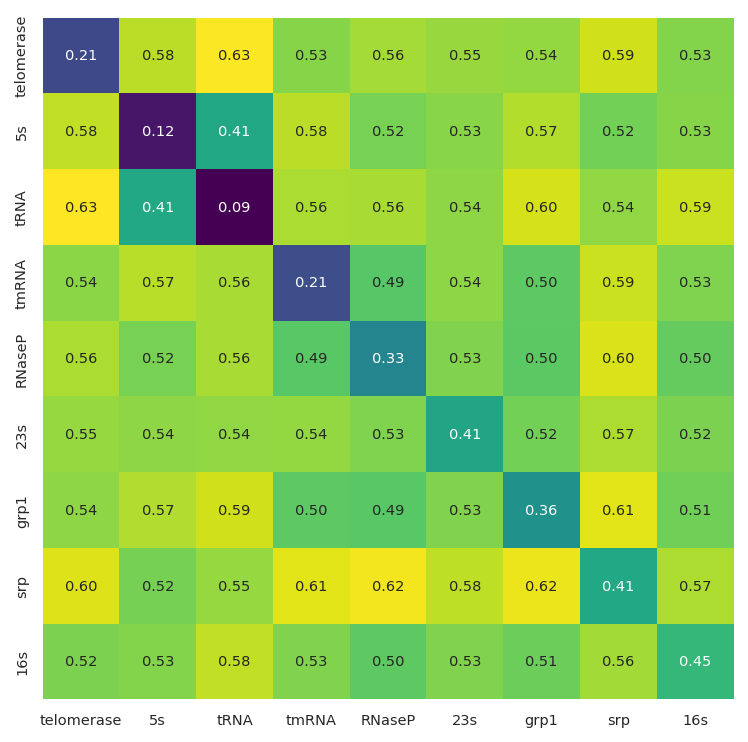

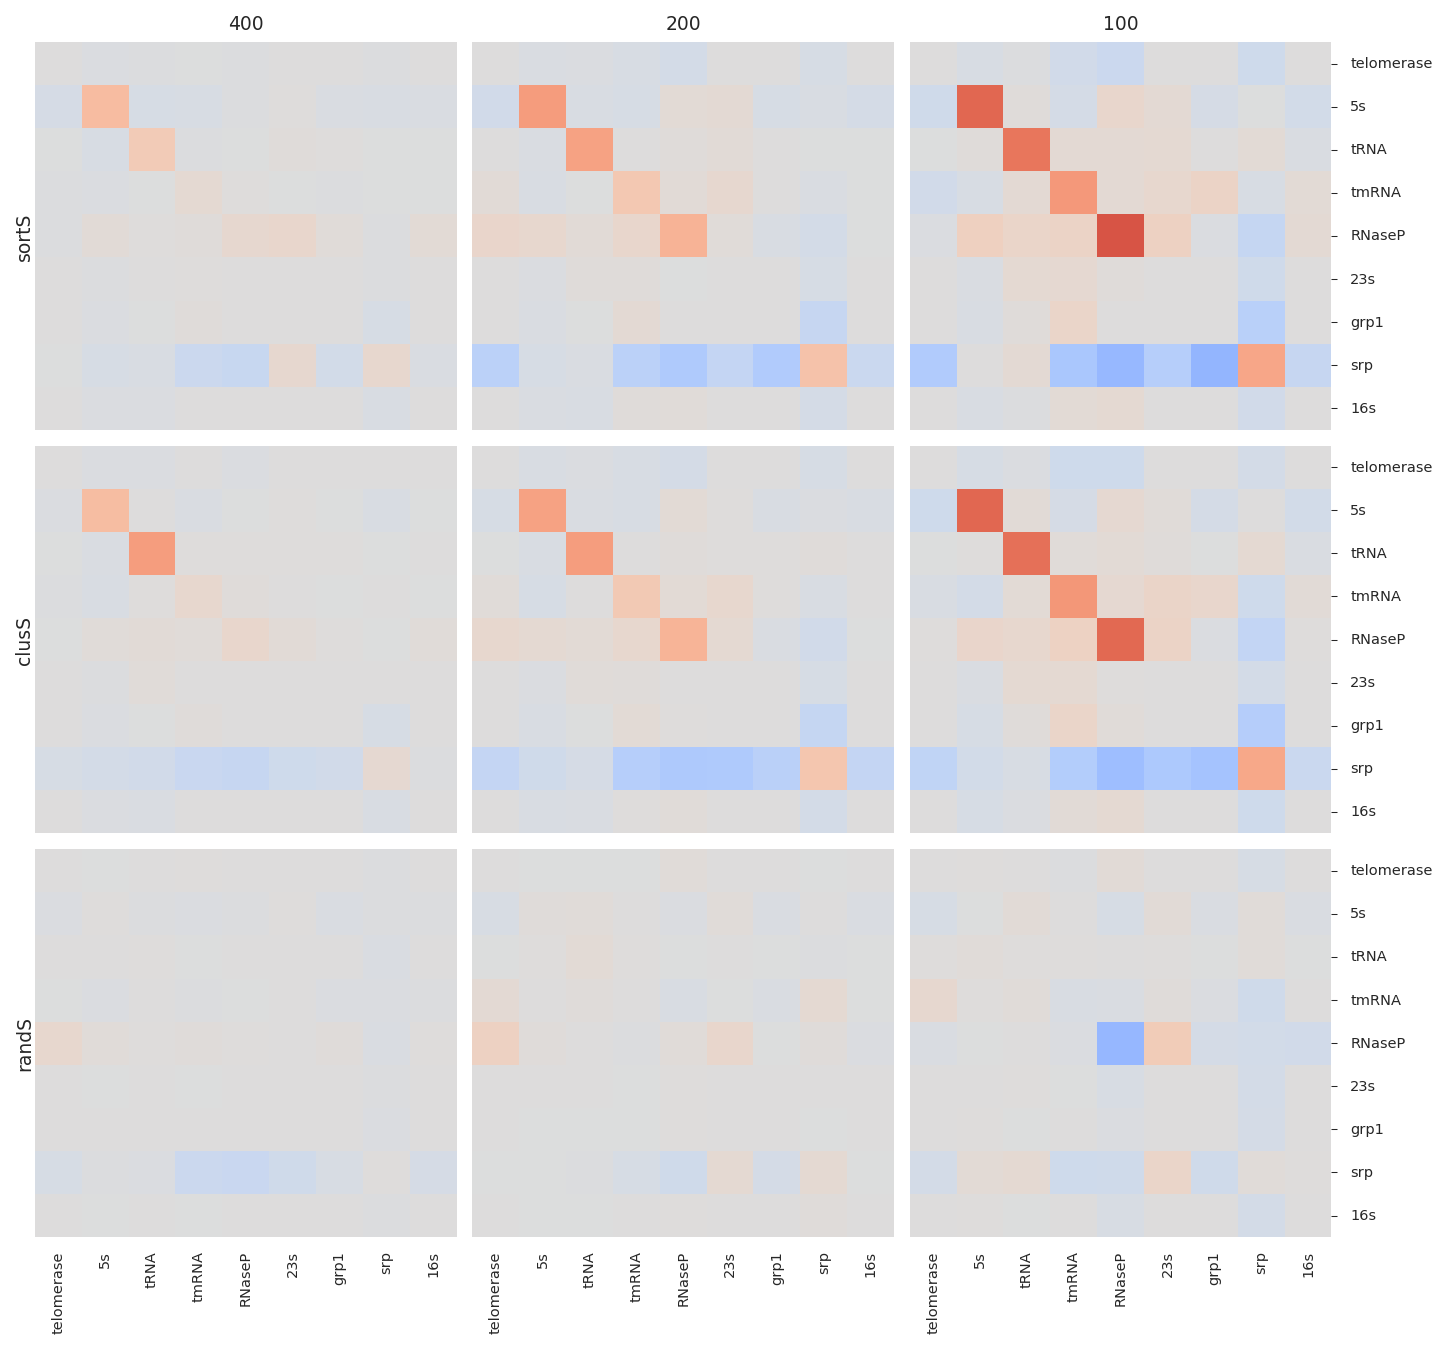

In [93]:
### means ###
plt.figure(figsize=(5, 5), dpi=150)
sns.heatmap(strategies["sortS"]["means"]["full"], annot=True, cmap="viridis", fmt=".2f", cbar=False)
plt.rcParams.update({'font.size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)
plt.tight_layout()
plt.savefig(save_path / "means_full.svg", dpi=150)
plt.show()

fig, ax = plt.subplots(3,3, figsize=(fig_width1col, fig_height), sharex=True, sharey=True, dpi=150)
plt.rcParams.update({'font.size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)

for row_idx, row in enumerate(["sortS", "clusS", "randS"]):
    for col_idx, col in enumerate(["dist400", "dist200","dist100"]):
        a = ax[row_idx, col_idx]
        sns.heatmap(
            delta_S[row]["means"][col],
            annot=False,
            cmap="coolwarm", 
            cbar=False, 
            vmin=-0.1, 
            vmax=0.1,
            ax=a
            )
        

        if row_idx == 0:
            a.set_title(col.replace("dist", ""), fontsize=font_size+2) 
        if col_idx == 0:
            a.set_ylabel(row, rotation=90, labelpad=5, va="center", fontsize=font_size+2)
        else:
            a.set_ylabel("")
            
        a.tick_params(axis="y", left=False, labelleft=False)
        if col_idx == 2:
            a.yaxis.tick_right()
            a.tick_params(axis="y", right=True, labelright=True, pad=6, labelsize=font_size)
            a.set_yticklabels(a.get_yticklabels(), rotation=0, ha="left", va="center")
plt.tight_layout()
plt.savefig(save_path / "means_methods.svg", dpi=150)
plt.show()

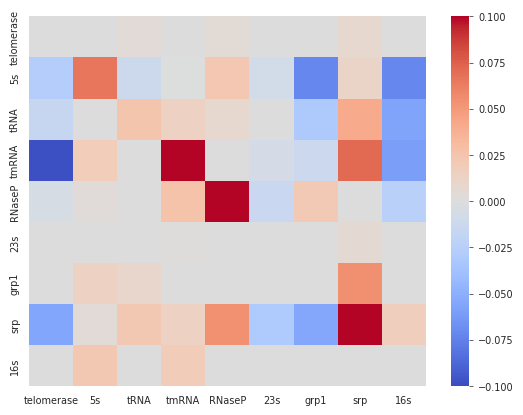

In [94]:

sns.heatmap(delta_S["sortS"]["mins"]["dist100"],
            annot=False, fmt=".2f",
            cmap="coolwarm", 
            cbar=True, 
            vmin=-0.1, 
            vmax=0.1)
plt.rcParams.update({'font.size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)

plt.savefig(save_path / "example_methods.svg", dpi=150)
plt.show()